# Non-Overlapping Patch Composition By Embedding Cluster

This notebook explores the validation-patch workflow used by `scripts/export_patch_composition_tables.py`.

1. Train a depth-2 `GINCurvature` model.
2. Cluster all validation nodes using their final local node embedding.
3. Sample strictly node-disjoint radius-2 patches using global marker-by-hop coverage targets followed by coverage-maximized filling.
4. Assign each patch the embedding cluster of its center cell.
5. Summarize patch marker composition by cluster.
6. Within each cluster, retain the 50% of patches with the smallest center-cell absolute prediction error and repeat the marker analysis.

Marker statistics treat each sampled patch as one observation and use the fraction of marker-positive cells within the patch.


**Setup**

In [84]:
import copy
import json
import pickle
import random
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_ROOT = PROJECT_ROOT / "training_data"
sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_ROOT    =", DATA_ROOT)
print("torch        =", torch.__version__)
print("cuda         =", torch.cuda.is_available())


PROJECT_ROOT = /home/fmoller/Projects/LearningOrganoids/GraphNN
DATA_ROOT    = /home/fmoller/Projects/LearningOrganoids/GraphNN/training_data
torch        = 2.8.0+cu128
cuda         = True


**Settings**

In [85]:
# Data and filtering. Defaults match export_patch_composition_tables.py.
EXPERIMENT_GROUP = "patch_composition_sampling_analysis"
DATASET_NAME = "fixed_new"
TARGET_INDICES = [0]
TARGET_INDEX_FOR_ANALYSIS = 0
EXCLUDE_TIMEPOINT = "day3p5"  # Set to None to retain every timepoint.
FILTER_BLACKLISTED_ORGANOIDS = True
APPLY_QUALITY_FILTERS = True
USE_GLOBAL_FEATURES = True
SUBTRACT_GLOBAL_BASELINE = False

MISSING_COMPLEXITY_GROUP = {
    "dataset": "20251201",
    "timepoint": "day4p5",
    "fill_value": 2.1,
}
SPHERICITY_MAX = 0.92
SPHERICAL_MARKER_DIVERSITY_MIN = 0.5
COMPLEXITY_MIN = 2.0
INTERPOLATE_TARGET_OUTLIERS = True
OUTLIER_CLIP_QUANTILES = (0.005, 0.995)

# Train/validation split
VAL_FRAC = 0.2
SPLIT_SEED = 0

# Depth-2 model
NUM_LAYERS = 2
HIDDEN_DIM = 4 * 64
DROPOUT = 0.1
NORM = "batch"
RESIDUAL = True
LR = 3e-4
BATCH_SIZE = 128
MAX_EPOCHS = 2000
PATIENCE = 30
NUM_WORKERS = 4
EDGE_LOSS_WEIGHT = 0.20
EDGE_LOSS_PARAMS = {
    "weighted": False,
    "alpha": 2.0,
    "normalize_by": "graph_std",
    "clip_weight": 4.0,
}

# Embedding clustering
N_CLUSTERS = 9
EMBEDDING_VARIANT = "local"
RESIDUALIZE_GLOBAL_FOR_CLUSTERING = False
CLUSTERING_METHOD = "gmm"
COVARIANCE_TYPE = "full"
STANDARDIZE_EMBEDDINGS = True
PCA_DIM = 32
CLUSTER_SEED = 0

# Strictly non-overlapping, two-stage patch sampling
PATCH_RADIUS = 2
MIN_MARKER_HOP_COVERAGE = 100
COVERAGE_CANDIDATE_POOL = 2000  # Set to None for exhaustive stage-1 scoring.
MAX_STAGE2_PATCHES = None  # None fills to a maximal packing; an integer caps stage 2 only.
PATCH_SEED = 0

# Accuracy filtering
ACCURATE_PATCH_FRACTION = 0.50
ACCURATE_PATCH_MIN_PER_CLUSTER = 1

# Output
RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_NAME = (
    f"depth{NUM_LAYERS}_clusters{N_CLUSTERS}_radius{PATCH_RADIUS}_"
    f"accurate{int(100 * ACCURATE_PATCH_FRACTION)}_{RUN_TIMESTAMP}"
)
SAVE_DIR = PROJECT_ROOT / "results_experiments" / EXPERIMENT_GROUP / RUN_NAME
FIGURES_DIR = SAVE_DIR / "figures"
TABLES_DIR = SAVE_DIR / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

random.seed(SPLIT_SEED)
np.random.seed(SPLIT_SEED)
torch.manual_seed(SPLIT_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SPLIT_SEED)


**Helpers**

In [86]:
def save_figure(fig, name, *, dpi=300):
    for suffix in ("pdf", "png"):
        fig.savefig(FIGURES_DIR / f"{name}.{suffix}", dpi=dpi, bbox_inches="tight")


def select_target_column(values, target_index=0):
    arr = np.asarray(values)
    if arr.ndim == 1:
        return arr
    return arr[:, int(target_index)]


def jsonable(value):
    if isinstance(value, dict):
        return {str(k): jsonable(v) for k, v in value.items()}
    if isinstance(value, (list, tuple, set)):
        return [jsonable(v) for v in value]
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, torch.Tensor):
        return value.detach().cpu().tolist()
    if isinstance(value, (torch.dtype, np.dtype)):
        return str(value)
    return value


def split_flat_by_graph(values, graphs):
    values = np.asarray(values)
    output = []
    offset = 0
    for graph in graphs:
        n_nodes = int(graph.x.shape[0])
        output.append(values[offset:offset + n_nodes].copy())
        offset += n_nodes
    if offset != len(values):
        raise ValueError(f"Consumed {offset} values but received {len(values)}.")
    return output


## 1. Load And Filter Data

In [87]:
from src.data.filters import (
    filter_graphs_by_blacklist,
    filter_graphs_by_marker_diversity,
    filter_graphs_by_metadata,
    filter_graphs_by_numeric_metadata,
    filter_graphs_by_sphericity,
    load_graph_blacklist_from_dir,
)
from src.data.io import load_graph_dataset_from_dir, select_graph_targets
from src.data.metadata import (
    add_log_metadata_features,
    attach_metadata_to_graphs,
    fill_missing_metadata_for_group,
    infer_global_dim,
    load_aux_metadata_for_dir,
    load_marker_names_from_dir,
    promote_metadata_to_graph_tensors,
    snapshot_graph_metadata,
    strip_graph_metadata,
)
from src.data.preprocessing import interpolate_target_outliers_from_neighbors

data_dir = DATA_ROOT / DATASET_NAME
graphs = load_graph_dataset_from_dir(str(data_dir))
metadata = load_aux_metadata_for_dir(str(data_dir))
attach_metadata_to_graphs(graphs, metadata, exclude_keys=None)
graphs = select_graph_targets(graphs, target_indices=TARGET_INDICES, inplace=False)
marker_names = load_marker_names_from_dir(str(data_dir))
if marker_names is None:
    marker_names = [f"marker_{i}" for i in range(int(graphs[0].x.shape[1]))]
marker_names = list(marker_names)
print(f"Loaded {len(graphs)} organoids and {len(marker_names)} markers.")


Loaded 1423 graphs; skipped 0.
Loaded 1423 organoids and 7 markers.


In [88]:
if EXCLUDE_TIMEPOINT:
    graphs = filter_graphs_by_metadata(
        graphs,
        key="timepoint",
        drop_values={EXCLUDE_TIMEPOINT},
        missing="keep",
        inplace=False,
        print_summary=True,
    )

if FILTER_BLACKLISTED_ORGANOIDS:
    blacklist = load_graph_blacklist_from_dir(data_dir)
    graphs = filter_graphs_by_blacklist(graphs, blacklist, print_summary=True)
else:
    blacklist = set()

if APPLY_QUALITY_FILTERS:
    graphs = fill_missing_metadata_for_group(
        graphs,
        field="complexity",
        fill_value=MISSING_COMPLEXITY_GROUP["fill_value"],
        dataset=MISSING_COMPLEXITY_GROUP["dataset"],
        timepoint=MISSING_COMPLEXITY_GROUP["timepoint"],
    )
    graphs, spherical = filter_graphs_by_sphericity(
        graphs,
        max_sphericity=SPHERICITY_MAX,
        print_summary=True,
        return_rejected=True,
    )
    _ = filter_graphs_by_marker_diversity(
        spherical,
        min_score=SPHERICAL_MARKER_DIVERSITY_MIN,
        print_summary=True,
    )
    graphs = filter_graphs_by_numeric_metadata(
        graphs,
        key="complexity",
        min_value=COMPLEXITY_MIN,
        allow_missing=False,
        inplace=False,
        print_summary=True,
    )

if INTERPOLATE_TARGET_OUTLIERS:
    graphs, target_outlier_info = interpolate_target_outliers_from_neighbors(
        graphs,
        clip_quantiles=OUTLIER_CLIP_QUANTILES,
    )
else:
    target_outlier_info = None

print(f"After filtering: {len(graphs)} organoids.")


filter_graphs_by_metadata(key='timepoint'): kept 1134 / 1423 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day3p5                0    289    0.000
20250929         day4                342    342    1.000
20250929         day4p5              104    104    1.000
20250929         day4p5-more         411    411    1.000
20251201         day4p5              277    277    1.000
filter_graphs_by_blacklist(n_keys=6): kept 1128 / 1134 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day4                341    342    0.997
20250929         day4p5              104    104    1.000
20250929         day4p5-more         409    411    0.995
20251201         day4p5              274    277    0.989
filter_graphs_by_sphericity(max_sphericity=0.92): kept 813 / 1128 graphs

dataset          timepoint          kept  total  

## 2. Split And Train A Depth-2 Model

In [89]:
from src.data.splits import graph_metadata_key, train_val_split_graphs
from src.data.target_transforms import (
    AsinhStandardizeTransform,
    ChainedTargetTransform,
    GlobalBaselineResidualTransform,
    standardize_graph_global_features,
)
from src.models.gnn import GINCurvature
from src.training.loop import TrainConfig, train
from src.training.losses import WeightedLossTerm, edge_loss_term

FIELD_SPECS = [{
    "meta_keys": ["log_surface_area", "log_volume", "log_volume_over_area", "log_num_cells"],
    "attr_name": "global_feat",
    "kind": "graph_vector",
    "dtype": torch.float32,
}]

if USE_GLOBAL_FEATURES:
    graphs = promote_metadata_to_graph_tensors(
        add_log_metadata_features(graphs, inplace=False),
        FIELD_SPECS,
        inplace=False,
    )

g_train_raw, g_val_raw, split_info = train_val_split_graphs(
    graphs,
    val_frac=VAL_FRAC,
    seed=SPLIT_SEED,
    key_fn=graph_metadata_key,
    inplace=False,
)
g_train = strip_graph_metadata(copy.deepcopy(g_train_raw), inplace=False)
g_val = strip_graph_metadata(copy.deepcopy(g_val_raw), inplace=False)
val_metadata_lookup = snapshot_graph_metadata(g_val_raw)

if USE_GLOBAL_FEATURES:
    standardize_graph_global_features(
        g_train,
        g_val,
        attr_name="global_feat",
        robust=False,
    )

if SUBTRACT_GLOBAL_BASELINE:
    target_transform = ChainedTargetTransform([
        GlobalBaselineResidualTransform(
            hidden_dim=HIDDEN_DIM,
            dropout=DROPOUT,
            lr=LR,
            batch_size=BATCH_SIZE,
            max_epochs=MAX_EPOCHS,
            patience=PATIENCE,
            num_workers=NUM_WORKERS,
        ),
        AsinhStandardizeTransform(robust=True),
    ])
else:
    target_transform = AsinhStandardizeTransform(robust=True)

target_transform.fit(g_train)
target_transform.transform_graphs(g_train, in_place=True)
target_transform.transform_graphs(g_val, in_place=True)
print(f"Split -> train: {len(g_train)} | validation: {len(g_val)}")


Split -> train: 565 | validation: 141


In [90]:
model = GINCurvature(
    n_markers=int(g_train[0].x.shape[1]),
    global_dim=infer_global_dim(g_train),
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    residual=RESIDUAL,
    norm=NORM,
)
train_config = TrainConfig(
    lr=LR,
    batch_size=BATCH_SIZE,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    num_workers=NUM_WORKERS,
    aux_losses=[WeightedLossTerm(
        name="edge",
        fn=edge_loss_term,
        weight=EDGE_LOSS_WEIGHT,
        params=EDGE_LOSS_PARAMS,
    )],
)
model, metrics, history = train(model, g_train, g_val, train_config)
print(metrics)


epoch 001 | train loss 0.5873 mae 0.8188 | val loss 0.4822 mae 0.7672
epoch 002 | train loss 0.4947 mae 0.7506 | val loss 0.4525 mae 0.7473
epoch 003 | train loss 0.4606 mae 0.7304 | val loss 0.4230 mae 0.7177
epoch 004 | train loss 0.4394 mae 0.7163 | val loss 0.4058 mae 0.7092
epoch 005 | train loss 0.4227 mae 0.7034 | val loss 0.3800 mae 0.6897
epoch 006 | train loss 0.4072 mae 0.6970 | val loss 0.3798 mae 0.6888
epoch 007 | train loss 0.3979 mae 0.6891 | val loss 0.3555 mae 0.6700
epoch 008 | train loss 0.3921 mae 0.6880 | val loss 0.3461 mae 0.6622
epoch 009 | train loss 0.3853 mae 0.6800 | val loss 0.3467 mae 0.6695
epoch 010 | train loss 0.3780 mae 0.6782 | val loss 0.3367 mae 0.6598
epoch 011 | train loss 0.3748 mae 0.6754 | val loss 0.3367 mae 0.6632
epoch 012 | train loss 0.3713 mae 0.6742 | val loss 0.3197 mae 0.6480
epoch 013 | train loss 0.3681 mae 0.6721 | val loss 0.3214 mae 0.6452
epoch 014 | train loss 0.3660 mae 0.6712 | val loss 0.3111 mae 0.6434
epoch 015 | train lo

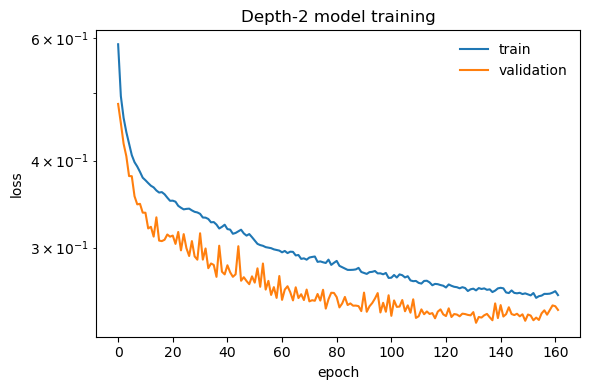

In [91]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(history["train_loss"], label="train")
ax.plot(history["val_loss"], label="validation")
ax.set_yscale("log")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_title("Depth-2 model training")
ax.legend(frameon=False)
fig.tight_layout()
save_figure(fig, "training_loss")
plt.show()


## 3. Cluster Validation Node Embeddings

In [92]:
from src.analysis.motif_clustering import run_embedding_clustering

extraction, clustering_result, cluster_summary_raw = run_embedding_clustering(
    graphs=g_val,
    model=model,
    batch_size=BATCH_SIZE,
    center_only=False,
    embedding_variant=EMBEDDING_VARIANT,
    residualize_global=RESIDUALIZE_GLOBAL_FOR_CLUSTERING,
    clustering=CLUSTERING_METHOD,
    n_clusters=N_CLUSTERS,
    covariance_type=COVARIANCE_TYPE,
    standardize=STANDARDIZE_EMBEDDINGS,
    pca_dim=PCA_DIM,
    seed=CLUSTER_SEED,
    marker_names=marker_names,
)

y_true, y_pred, log_var = target_transform.inverse_distribution(
    extraction.y_true,
    extraction.y_pred,
    log_var=extraction.log_var,
    graphs=g_val,
)
y_true = select_target_column(y_true, TARGET_INDEX_FOR_ANALYSIS)
y_pred = select_target_column(y_pred, TARGET_INDEX_FOR_ANALYSIS)
labels = np.asarray(clustering_result.labels, dtype=int)

# Relabel clusters by median true curvature for stable, interpretable display order.
unique_labels = np.sort(np.unique(labels))
cluster_medians = {
    int(cluster): float(np.nanmedian(y_true[labels == cluster]))
    for cluster in unique_labels
}
old_to_new = {
    old: new
    for new, old in enumerate(sorted(unique_labels, key=lambda x: cluster_medians[int(x)]))
}
labels = np.asarray([old_to_new[int(label)] for label in labels], dtype=int)
clustering_result.labels = labels

labels_by_graph = split_flat_by_graph(labels, g_val_raw)
y_true_by_graph = split_flat_by_graph(y_true, g_val_raw)
y_pred_by_graph = split_flat_by_graph(y_pred, g_val_raw)

cluster_summary_df = pd.DataFrame([{
    "cluster": int(cluster),
    "n_validation_nodes": int(np.sum(labels == cluster)),
    "median_true_curvature": float(np.nanmedian(y_true[labels == cluster])),
    "mean_true_curvature": float(np.nanmean(y_true[labels == cluster])),
    "mean_predicted_curvature": float(np.nanmean(y_pred[labels == cluster])),
    "median_absolute_error": float(
        np.nanmedian(np.abs(y_pred[labels == cluster] - y_true[labels == cluster]))
    ),
} for cluster in np.sort(np.unique(labels))])
display(cluster_summary_df)


,cluster,n_validation_nodes,median_true_curvature,mean_true_curvature,mean_predicted_curvature,median_absolute_error
0,0,6110,0.009496,-0.003563,0.004748,0.023872
1,1,6079,0.019517,0.019902,0.024189,0.017674
2,2,6483,0.027556,0.022423,0.023283,0.022908
3,3,8057,0.031175,0.032482,0.030837,0.026592
4,4,6419,0.031378,0.022555,0.025675,0.020485
5,5,8908,0.031414,0.025614,0.029836,0.020416
6,6,9928,0.044038,0.042496,0.041074,0.016488
7,7,7023,0.054104,0.058702,0.055089,0.022955
8,8,6623,0.067362,0.071739,0.063561,0.030931


## 4. Sample Strictly Non-Overlapping Radius-2 Patches

In [93]:
from scripts.export_patch_composition_tables import (
    build_adjacency,
    graph_identity,
    original_node_id,
)


def exact_hop_rings_from_adjacency(adjacency, center, max_hops):
    visited = {int(center)}
    frontier = {int(center)}
    rings = [[int(center)]]
    for _ in range(int(max_hops)):
        next_frontier = set()
        for node in frontier:
            next_frontier.update(adjacency[node])
        next_frontier.difference_update(visited)
        rings.append(sorted(next_frontier))
        visited.update(next_frontier)
        frontier = next_frontier
    return rings


def build_global_patch_candidates(graphs, marker_names, *, radius):
    n_features = (int(radius) + 1) * len(marker_names)
    features = []
    graph_indices = []
    centers = []
    patch_nodes = []
    exact_rings = []
    conflict_centers_local = []
    graph_offsets = []
    offset = 0

    for graph_idx, graph in enumerate(graphs):
        graph_offsets.append(offset)
        adjacency = build_adjacency(graph)
        x_positive = graph.x.detach().cpu().numpy() > 0.5
        n_nodes = int(graph.x.shape[0])
        for center in range(n_nodes):
            rings = exact_hop_rings_from_adjacency(
                adjacency,
                center,
                2 * int(radius),
            )
            patch_ring_nodes = rings[: int(radius) + 1]
            patch = np.asarray(
                sorted({node for ring in patch_ring_nodes for node in ring}),
                dtype=np.int64,
            )
            conflict = np.asarray(
                sorted({node for ring in rings for node in ring}),
                dtype=np.int64,
            )
            feature_matrix = np.zeros(
                (int(radius) + 1, len(marker_names)),
                dtype=bool,
            )
            for hop, ring in enumerate(patch_ring_nodes):
                if ring:
                    feature_matrix[hop] = x_positive[
                        np.asarray(ring, dtype=np.int64)
                    ].any(axis=0)

            graph_indices.append(graph_idx)
            centers.append(center)
            patch_nodes.append(patch)
            exact_rings.append([
                np.asarray(ring, dtype=np.int64)
                for ring in patch_ring_nodes
            ])
            conflict_centers_local.append(conflict)
            features.append(feature_matrix.reshape(n_features))
        offset += n_nodes

    graph_offsets = np.asarray(graph_offsets, dtype=np.int64)
    graph_indices = np.asarray(graph_indices, dtype=np.int64)
    centers = np.asarray(centers, dtype=np.int64)
    features = np.asarray(features, dtype=bool)
    conflict_candidate_ids = [
        graph_offsets[graph_idx] + local_centers
        for graph_idx, local_centers in zip(
            graph_indices,
            conflict_centers_local,
        )
    ]
    return {
        "features": features,
        "graph_indices": graph_indices,
        "centers": centers,
        "patch_nodes": patch_nodes,
        "exact_rings": exact_rings,
        "conflict_candidate_ids": conflict_candidate_ids,
    }


def sample_two_stage_non_overlapping_patches(
    graphs,
    marker_names,
    *,
    radius,
    min_marker_hop_coverage,
    candidate_pool_size,
    max_stage2_patches,
    seed,
):
    if max_stage2_patches is not None and int(max_stage2_patches) < 0:
        raise ValueError("max_stage2_patches must be non-negative or None.")

    candidates = build_global_patch_candidates(
        graphs,
        marker_names,
        radius=radius,
    )
    features = candidates["features"]
    n_candidates, n_features = features.shape
    rng = np.random.default_rng(seed)
    available = np.ones(n_candidates, dtype=bool)
    coverage = np.zeros(n_features, dtype=np.int64)
    possible = features.sum(axis=0).astype(np.int64)
    requested = np.full(
        n_features,
        int(min_marker_hop_coverage),
        dtype=np.int64,
    )
    selected_ids = []
    selected_stages = []
    feature_candidates = [
        np.flatnonzero(features[:, feature_idx])
        for feature_idx in range(n_features)
    ]

    def select_candidate(candidate_id, stage):
        candidate_id = int(candidate_id)
        selected_ids.append(candidate_id)
        selected_stages.append(stage)
        coverage[:] += features[candidate_id]
        available[candidates["conflict_candidate_ids"][candidate_id]] = False

    # Stage 1: target overall support for every marker at every exact hop.
    while np.any(coverage < requested):
        unsatisfied = np.flatnonzero(coverage < requested)
        relative_coverage = coverage[unsatisfied] / np.maximum(
            requested[unsatisfied],
            1,
        )
        priority_order = unsatisfied[
            np.lexsort((possible[unsatisfied], relative_coverage))
        ]
        chosen = None
        for feature_idx in priority_order:
            eligible = feature_candidates[int(feature_idx)]
            eligible = eligible[available[eligible]]
            if len(eligible) == 0:
                continue
            if candidate_pool_size is not None and len(eligible) > int(candidate_pool_size):
                eligible = rng.choice(
                    eligible,
                    size=int(candidate_pool_size),
                    replace=False,
                )

            unmet = coverage < requested
            rarity_weights = unmet / np.maximum(possible, 1)
            scores = features[eligible].astype(float) @ rarity_weights
            patch_sizes = np.asarray(
                [len(candidates["patch_nodes"][int(idx)]) for idx in eligible],
                dtype=float,
            )
            scores += 1e-6 / np.maximum(patch_sizes, 1)
            best = np.flatnonzero(scores == scores.max())
            chosen = int(eligible[int(rng.choice(best))])
            break
        if chosen is None:
            break
        select_candidate(chosen, "minimum_coverage")

    stage1_coverage = coverage.copy()

    # Stage 2: fill to a maximal disjoint packing, prioritizing features that
    # remain uncommon in the stage-1 sample.
    feature_weights = 1.0 / (stage1_coverage + 1.0)
    stage2_scores = features.astype(float) @ feature_weights
    patch_sizes = np.asarray(
        [len(nodes) for nodes in candidates["patch_nodes"]],
        dtype=float,
    )
    stage2_scores += 1e-3 / np.maximum(patch_sizes, 1)
    stage2_scores += rng.uniform(0, 1e-9, size=n_candidates)
    n_stage2_selected = 0
    for candidate_id in np.argsort(-stage2_scores):
        if (
            max_stage2_patches is not None
            and n_stage2_selected >= int(max_stage2_patches)
        ):
            break
        if available[int(candidate_id)]:
            select_candidate(int(candidate_id), "coverage_maximization")
            n_stage2_selected += 1

    selected = []
    for candidate_id, stage in zip(selected_ids, selected_stages):
        selected.append({
            "candidate_id": int(candidate_id),
            "graph_index": int(candidates["graph_indices"][candidate_id]),
            "center": int(candidates["centers"][candidate_id]),
            "patch_nodes": candidates["patch_nodes"][candidate_id],
            "exact_rings": candidates["exact_rings"][candidate_id],
            "features": features[candidate_id].reshape(
                int(radius) + 1,
                len(marker_names),
            ),
            "sampling_stage": stage,
        })

    rows = []
    final_coverage = coverage.copy()
    for hop in range(int(radius) + 1):
        for marker_idx, marker in enumerate(marker_names):
            feature_idx = hop * len(marker_names) + marker_idx
            rows.append({
                "hop": hop,
                "marker_index": marker_idx,
                "marker": marker,
                "requested_minimum": int(requested[feature_idx]),
                "candidate_centers_available": int(possible[feature_idx]),
                "stage1_selected_patches": int(stage1_coverage[feature_idx]),
                "final_selected_patches": int(final_coverage[feature_idx]),
                "minimum_achieved": bool(
                    stage1_coverage[feature_idx] >= requested[feature_idx]
                ),
            })
    return selected, pd.DataFrame(rows), candidates


def verify_global_patch_disjointness(selected_patches):
    used_by_graph = {}
    for patch in selected_patches:
        graph_idx = int(patch["graph_index"])
        used = used_by_graph.setdefault(graph_idx, set())
        node_set = set(int(node) for node in patch["patch_nodes"])
        if used.intersection(node_set):
            return False
        used.update(node_set)
    return True


In [94]:
selected_patches, marker_hop_coverage_df, patch_candidates = (
    sample_two_stage_non_overlapping_patches(
        g_val_raw,
        marker_names,
        radius=PATCH_RADIUS,
        min_marker_hop_coverage=MIN_MARKER_HOP_COVERAGE,
        candidate_pool_size=COVERAGE_CANDIDATE_POOL,
        max_stage2_patches=MAX_STAGE2_PATCHES,
        seed=PATCH_SEED,
    )
)
if not verify_global_patch_disjointness(selected_patches):
    raise RuntimeError("The two-stage sampler produced overlapping patches.")

patches_by_graph = {graph_idx: [] for graph_idx in range(len(g_val_raw))}
for patch in selected_patches:
    patches_by_graph[patch["graph_index"]].append(patch)

patch_rows = []
organoid_sampling_rows = []
for graph_idx, graph in enumerate(g_val_raw):
    graph_patches = sorted(
        patches_by_graph[graph_idx],
        key=lambda patch: patch["center"],
    )
    x = graph.x.detach().cpu().numpy()
    identity = graph_identity(graph)
    n_sampled_cells = sum(len(patch["patch_nodes"]) for patch in graph_patches)
    organoid_sampling_rows.append({
        "graph_index": graph_idx,
        **identity,
        "n_organoid_cells": int(graph.x.shape[0]),
        "n_patches": len(graph_patches),
        "n_minimum_coverage_patches": sum(
            patch["sampling_stage"] == "minimum_coverage"
            for patch in graph_patches
        ),
        "n_coverage_maximization_patches": sum(
            patch["sampling_stage"] == "coverage_maximization"
            for patch in graph_patches
        ),
        "n_cells_in_sampled_patches": n_sampled_cells,
        "sampled_cell_fraction": (
            n_sampled_cells / int(graph.x.shape[0])
            if int(graph.x.shape[0]) > 0
            else np.nan
        ),
        "patches_are_node_disjoint": True,
    })

    for patch_index, patch in enumerate(graph_patches):
        center = patch["center"]
        patch_nodes = patch["patch_nodes"]
        patch_x = x[patch_nodes]
        row = {
            "graph_index": graph_idx,
            **identity,
            "patch_index": patch_index,
            "candidate_id": patch["candidate_id"],
            "sampling_stage": patch["sampling_stage"],
            "center_node_id": center,
            "center_node_original_id": original_node_id(graph, center),
            "patch_radius": PATCH_RADIUS,
            "patch_node_ids": json.dumps([int(node) for node in patch_nodes]),
            "n_cells_patch": len(patch_nodes),
            "cluster": int(labels_by_graph[graph_idx][center]),
            "center_true_curvature": float(y_true_by_graph[graph_idx][center]),
            "center_predicted_curvature": float(y_pred_by_graph[graph_idx][center]),
        }
        row["center_absolute_error"] = abs(
            row["center_predicted_curvature"] - row["center_true_curvature"]
        )
        for marker_idx, marker in enumerate(marker_names):
            positive = patch_x[:, marker_idx] > 0.5
            row[f"n_marker_{marker_idx}_positive"] = int(positive.sum())
            row[f"frac_marker_{marker_idx}_positive"] = float(positive.mean())
            row[f"center_marker_{marker_idx}_positive"] = int(
                x[center, marker_idx] > 0.5
            )
            for hop in range(PATCH_RADIUS + 1):
                row[f"hop_{hop}_marker_{marker_idx}_present"] = int(
                    patch["features"][hop, marker_idx]
                )
        patch_rows.append(row)

patch_df = pd.DataFrame(patch_rows)
organoid_sampling_df = pd.DataFrame(organoid_sampling_rows)
print(
    f"Sampled {len(patch_df):,} non-overlapping patches: "
    f"{sum(patch['sampling_stage'] == 'minimum_coverage' for patch in selected_patches):,} "
    "for minimum coverage and "
    f"{sum(patch['sampling_stage'] == 'coverage_maximization' for patch in selected_patches):,} "
    "during coverage maximization."
)
display(marker_hop_coverage_df)
display(organoid_sampling_df.describe(include="all"))


Sampled 2,164 non-overlapping patches: 326 for minimum coverage and 1,838 during coverage maximization.


,hop,marker_index,marker,requested_minimum,candidate_centers_available,stage1_selected_patches,final_selected_patches,minimum_achieved
0,0,0,Agr2,100,3547,112,308,True
1,0,1,AldoB,100,25772,100,1069,True
2,0,2,Chroma,100,301,66,66,False
3,0,3,KI67,100,21576,155,901,True
4,0,4,LGR5,100,8900,100,402,True
5,0,5,Lysozyme,100,956,100,128,True
6,0,6,Serotonin,100,228,60,60,False
7,1,0,Agr2,100,14202,143,690,True
8,1,1,AldoB,100,32887,116,1196,True
9,1,2,Chroma,100,1290,79,79,False


,graph_index,organoid_str,organoid_id,label_uid,dataset,timepoint,n_organoid_cells,n_patches,n_minimum_coverage_patches,n_coverage_maximization_patches,n_cells_in_sampled_patches,sampled_cell_fraction,patches_are_node_disjoint
count,141.000000,141,141,141,141,141,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,141
unique,NaN,141,141,141,2,3,NaN,NaN,NaN,NaN,NaN,NaN,1
top,NaN,organoid_day4_A02_14,day4_A02_14,day4_A02_14,20250929,day4p5,NaN,NaN,NaN,NaN,NaN,NaN,True
freq,NaN,1,1,1,105,54,NaN,NaN,NaN,NaN,NaN,NaN,141
mean,70.000000,NaN,NaN,NaN,NaN,NaN,465.460993,15.347518,2.312057,13.035461,282.794326,0.613086,NaN
std,40.847277,NaN,NaN,NaN,NaN,NaN,272.733190,8.774139,1.749019,8.271648,162.916785,0.051564,NaN
min,0.000000,NaN,NaN,NaN,NaN,NaN,59.000000,2.000000,0.000000,1.000000,35.000000,0.474026,NaN
25%,35.000000,NaN,NaN,NaN,NaN,NaN,273.000000,9.000000,1.000000,7.000000,160.000000,0.581756,NaN
50%,70.000000,NaN,NaN,NaN,NaN,NaN,417.000000,14.000000,2.000000,11.000000,256.000000,0.605512,NaN
75%,105.000000,NaN,NaN,NaN,NaN,NaN,632.000000,21.000000,3.000000,18.000000,368.000000,0.645609,NaN


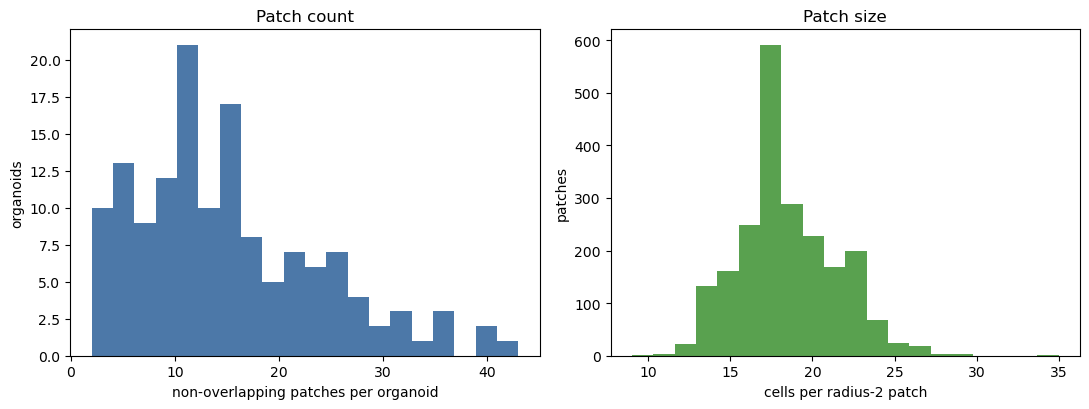

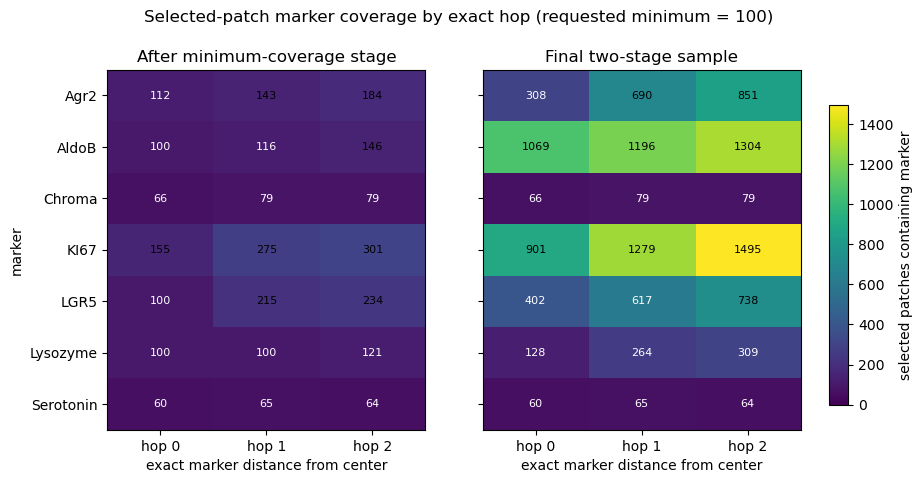

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].hist(organoid_sampling_df["n_patches"], bins=20, color="#4C78A8")
axes[0].set_xlabel("non-overlapping patches per organoid")
axes[0].set_ylabel("organoids")
axes[0].set_title("Patch count")

axes[1].hist(patch_df["n_cells_patch"], bins=20, color="#59A14F")
axes[1].set_xlabel("cells per radius-2 patch")
axes[1].set_ylabel("patches")
axes[1].set_title("Patch size")
fig.tight_layout()
save_figure(fig, "patch_sampling_distributions")
plt.show()


coverage_table = (
    marker_hop_coverage_df.pivot(
        index="marker",
        columns="hop",
        values="final_selected_patches",
    )
    .reindex(index=marker_names, columns=range(PATCH_RADIUS + 1))
)
stage1_table = (
    marker_hop_coverage_df.pivot(
        index="marker",
        columns="hop",
        values="stage1_selected_patches",
    )
    .reindex(index=coverage_table.index, columns=coverage_table.columns)
)

coverage_vmax = float(max(stage1_table.to_numpy().max(), coverage_table.to_numpy().max()))
fig, axes = plt.subplots(1, 2, figsize=(9.5, 5.0), sharey=True)
images = []
for ax, table, title in [
    (axes[0], stage1_table, "After minimum-coverage stage"),
    (axes[1], coverage_table, "Final two-stage sample"),
]:
    image = ax.imshow(
        table.to_numpy(float),
        aspect="auto",
        cmap="viridis",
        vmin=0,
        vmax=coverage_vmax,
    )
    images.append(image)
    ax.set_xticks(range(PATCH_RADIUS + 1))
    ax.set_xticklabels([f"hop {hop}" for hop in range(PATCH_RADIUS + 1)])
    ax.set_yticks(range(len(marker_names)))
    ax.set_yticklabels(marker_names)
    ax.set_xlabel("exact marker distance from center")
    ax.set_title(title)
    for row in range(table.shape[0]):
        for col in range(table.shape[1]):
            value = table.iloc[row, col]
            ax.text(
                col,
                row,
                f"{int(value)}",
                ha="center",
                va="center",
                color="white" if value < table.to_numpy().max() * 0.45 else "black",
                fontsize=8,
            )
axes[0].set_ylabel("marker")
fig.suptitle(
    f"Selected-patch marker coverage by exact hop "
    f"(requested minimum = {MIN_MARKER_HOP_COVERAGE})"
)
fig.subplots_adjust(left=0.13, right=0.86, bottom=0.14, top=0.86, wspace=0.18)
colorbar_ax = fig.add_axes([0.89, 0.19, 0.02, 0.60])
colorbar = fig.colorbar(images[-1], cax=colorbar_ax)
colorbar.set_label("selected patches containing marker")
save_figure(fig, "marker_hop_sampling_coverage")
plt.show()


## 5. Marker Statistics By Center-Cell Cluster

In [96]:
def patch_marker_long_table(patches, stage):
    rows = []
    for marker_idx, marker in enumerate(marker_names):
        columns = [
            "graph_index",
            "organoid_str",
            "patch_index",
            "cluster",
            "center_absolute_error",
            "n_cells_patch",
            f"n_marker_{marker_idx}_positive",
            f"frac_marker_{marker_idx}_positive",
        ]
        marker_df = patches[columns].copy()
        marker_df = marker_df.rename(columns={
            f"n_marker_{marker_idx}_positive": "n_positive",
            f"frac_marker_{marker_idx}_positive": "fraction_positive",
        })
        marker_df["marker_index"] = marker_idx
        marker_df["marker"] = marker
        marker_df["stage"] = stage
        rows.append(marker_df)
    return pd.concat(rows, ignore_index=True)


def summarize_patch_markers(long_df):
    summary = (
        long_df.groupby(["stage", "cluster", "marker_index", "marker"], as_index=False)
        .agg(
            n_patches=("fraction_positive", "size"),
            mean_fraction_positive=("fraction_positive", "mean"),
            std_fraction_positive=("fraction_positive", "std"),
            median_fraction_positive=("fraction_positive", "median"),
            q25_fraction_positive=("fraction_positive", lambda x: x.quantile(0.25)),
            q75_fraction_positive=("fraction_positive", lambda x: x.quantile(0.75)),
            mean_positive_cells=("n_positive", "mean"),
            mean_patch_size=("n_cells_patch", "mean"),
        )
    )
    summary["std_fraction_positive"] = summary["std_fraction_positive"].fillna(0.0)
    summary["sem_fraction_positive"] = (
        summary["std_fraction_positive"]
        / np.sqrt(summary["n_patches"].clip(lower=1))
    )
    return summary


patch_marker_all_df = patch_marker_long_table(patch_df, "all_patches")
marker_summary_all_df = summarize_patch_markers(patch_marker_all_df)
display(marker_summary_all_df.head(12))


,stage,cluster,marker_index,marker,n_patches,mean_fraction_positive,std_fraction_positive,median_fraction_positive,q25_fraction_positive,q75_fraction_positive,mean_positive_cells,mean_patch_size,sem_fraction_positive
0,all_patches,0,0,Agr2,257,0.023163,0.039540,0.000000,0.000000,0.045455,0.470817,19.396887,0.002466
1,all_patches,0,1,AldoB,257,0.454336,0.195646,0.458333,0.294118,0.600000,8.750973,19.396887,0.012204
2,all_patches,0,2,Chroma,257,0.000185,0.002970,0.000000,0.000000,0.000000,0.003891,19.396887,0.000185
3,all_patches,0,3,KI67,257,0.308946,0.232266,0.238095,0.125000,0.444444,5.867704,19.396887,0.014488
4,all_patches,0,4,LGR5,257,0.008342,0.025780,0.000000,0.000000,0.000000,0.151751,19.396887,0.001608
5,all_patches,0,5,Lysozyme,257,0.002481,0.010836,0.000000,0.000000,0.000000,0.050584,19.396887,0.000676
6,all_patches,0,6,Serotonin,257,0.000229,0.003669,0.000000,0.000000,0.000000,0.003891,19.396887,0.000229
7,all_patches,1,0,Agr2,133,0.024236,0.039571,0.000000,0.000000,0.052632,0.451128,17.774436,0.003431
8,all_patches,1,1,AldoB,133,0.005657,0.019492,0.000000,0.000000,0.000000,0.105263,17.774436,0.001690
9,all_patches,1,2,Chroma,133,0.000342,0.003941,0.000000,0.000000,0.000000,0.007519,17.774436,0.000342


In [97]:
def plot_marker_fraction_heatmaps(
    all_summary,
    accurate_summary,
    *,
    filename,
):
    fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.0), sharey=True)
    stages = [
        (all_summary, "All non-overlapping patches"),
        (accurate_summary, "Best-predicted 50% within each cluster"),
    ]
    image = None
    for ax, (summary_df, title) in zip(axes, stages):
        table = (
            summary_df.pivot(
                index="cluster",
                columns="marker",
                values="mean_fraction_positive",
            )
            .reindex(columns=marker_names)
            .sort_index()
        )
        sem_table = (
            summary_df.pivot(
                index="cluster",
                columns="marker",
                values="sem_fraction_positive",
            )
            .reindex(index=table.index, columns=table.columns)
        )
        image = ax.imshow(table.to_numpy(float), aspect="auto", vmin=0, vmax=1, cmap="viridis")
        ax.set_xticks(np.arange(len(marker_names)))
        ax.set_xticklabels(marker_names, rotation=45, ha="right")
        ax.set_yticks(np.arange(len(table.index)))
        ax.set_yticklabels([f"C{cluster}" for cluster in table.index])
        ax.set_xlabel("marker")
        ax.set_title(title)
        for row in range(table.shape[0]):
            for col in range(table.shape[1]):
                mean = table.iloc[row, col]
                sem = sem_table.iloc[row, col]
                if np.isfinite(mean):
                    ax.text(
                        col,
                        row,
                        f"{mean:.2f}\n±{sem:.2f}",
                        ha="center",
                        va="center",
                        fontsize=7,
                        color="white" if mean < 0.35 else "black",
                    )
    axes[0].set_ylabel("center-cell embedding cluster")
    fig.suptitle("Patch marker composition by center-cell embedding cluster")
    fig.subplots_adjust(left=0.08, right=0.88, bottom=0.18, top=0.88, wspace=0.18)
    colorbar_ax = fig.add_axes([0.91, 0.20, 0.018, 0.62])
    colorbar = fig.colorbar(image, cax=colorbar_ax)
    colorbar.set_label("mean patch fraction positive")
    save_figure(fig, filename)
    plt.show()
    return fig, axes


def plot_patch_marker_distributions(long_df, title, filename):
    n_markers = len(marker_names)
    n_cols = min(4, n_markers)
    n_rows = int(np.ceil(n_markers / n_cols))
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4.0 * n_cols, 3.1 * n_rows),
        sharey=True,
        squeeze=False,
    )
    axes = axes.ravel()
    clusters = np.sort(long_df["cluster"].unique())
    for ax, marker in zip(axes, marker_names):
        marker_df = long_df[long_df["marker"] == marker]
        values = [
            marker_df.loc[marker_df["cluster"] == cluster, "fraction_positive"].to_numpy(float)
            for cluster in clusters
        ]
        boxplot = ax.boxplot(values, showfliers=False, patch_artist=True)
        for box in boxplot["boxes"]:
            box.set_facecolor("#4C78A8")
        ax.set_title(marker)
        ax.set_xticks(np.arange(1, len(clusters) + 1))
        ax.set_xticklabels([f"C{cluster}" for cluster in clusters], rotation=45)
        ax.set_ylim(-0.03, 1.03)
        ax.grid(axis="y", alpha=0.2)
    for ax in axes[n_markers:]:
        ax.set_visible(False)
    for row in range(n_rows):
        axes[row * n_cols].set_ylabel("patch fraction positive")
    fig.suptitle(title)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    save_figure(fig, filename)
    plt.show()
    return fig, axes



def plot_patch_curvature_boxplots(all_patches, accurate_patches, filename):
    from src.plotting.cluster_plots import plot_cluster_boxplots

    cluster_order = np.sort(all_patches["cluster"].unique())
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14.0, 4.8),
        sharex=True,
        sharey=True,
    )
    panels = [
        (all_patches, "All non-overlapping patches"),
        (accurate_patches, "Best-predicted 50% within each cluster"),
    ]
    for ax, (patches, title) in zip(axes, panels):
        plot_cluster_boxplots(
            [
                patches["center_true_curvature"].to_numpy(float),
                patches["center_predicted_curvature"].to_numpy(float),
            ],
            patches["cluster"].to_numpy(int),
            data_labels=["true", "predicted"],
            colors=["lightblue", "lightgreen"],
            cluster_order=cluster_order,
            show_outliers=False,
            ylabel="center-cell curvature",
            title=title,
            xlabel="center-cell embedding cluster",
            ax=ax,
        )
    fig.suptitle("True and predicted curvature of sampled patch centers")
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    save_figure(fig, filename)
    plt.show()
    return fig, axes


def marker_fraction_change_table(all_summary, accurate_summary):
    key_columns = ["cluster", "marker_index", "marker"]
    before = all_summary[
        key_columns + ["mean_fraction_positive", "sem_fraction_positive"]
    ].rename(columns={
        "mean_fraction_positive": "mean_fraction_before",
        "sem_fraction_positive": "sem_fraction_before",
    })
    after = accurate_summary[
        key_columns + ["mean_fraction_positive", "sem_fraction_positive"]
    ].rename(columns={
        "mean_fraction_positive": "mean_fraction_after",
        "sem_fraction_positive": "sem_fraction_after",
    })
    change = before.merge(after, on=key_columns, how="outer", validate="one_to_one")
    change["fraction_change_after_minus_before"] = (
        change["mean_fraction_after"] - change["mean_fraction_before"]
    )
    return change


def plot_marker_fraction_changes(change_df, filename):
    table = (
        change_df.pivot(
            index="cluster",
            columns="marker",
            values="fraction_change_after_minus_before",
        )
        .reindex(columns=marker_names)
        .sort_index()
    )
    values = table.to_numpy(float)
    finite = np.abs(values[np.isfinite(values)])
    limit = float(finite.max()) if finite.size else 1.0
    if limit == 0:
        limit = 1.0

    fig, ax = plt.subplots(figsize=(8.6, 5.2))
    image = ax.imshow(
        values,
        aspect="auto",
        cmap="RdBu_r",
        vmin=-limit,
        vmax=limit,
    )
    ax.set_xticks(np.arange(len(marker_names)))
    ax.set_xticklabels(marker_names, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(table.index)))
    ax.set_yticklabels([f"C{cluster}" for cluster in table.index])
    ax.set_xlabel("marker")
    ax.set_ylabel("center-cell embedding cluster")
    ax.set_title("Marker composition change after accuracy filtering")
    for row in range(table.shape[0]):
        for col in range(table.shape[1]):
            value = values[row, col]
            if np.isfinite(value):
                ax.text(
                    col,
                    row,
                    f"{value:+.2f}",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="white" if abs(value) > 0.55 * limit else "black",
                )
    fig.subplots_adjust(left=0.12, right=0.84, bottom=0.20, top=0.88)
    colorbar_ax = fig.add_axes([0.88, 0.20, 0.022, 0.62])
    colorbar = fig.colorbar(image, cax=colorbar_ax)
    colorbar.set_label("fraction after filtering - fraction before filtering")
    save_figure(fig, filename)
    plt.show()
    return fig, ax


## 6. Keep The Best-Predicted 50% Within Each Cluster

In [98]:
def best_patch_mask_by_cluster(
    patches,
    *,
    fraction,
    min_per_cluster=1,
):
    if not (0 < fraction <= 1):
        raise ValueError("fraction must lie in (0, 1].")
    keep = np.zeros(len(patches), dtype=bool)
    rows = []
    for cluster in np.sort(patches["cluster"].unique()):
        positions = np.flatnonzero(patches["cluster"].to_numpy() == cluster)
        errors = patches.iloc[positions]["center_absolute_error"].to_numpy(float)
        finite_positions = positions[np.isfinite(errors)]
        n_available = len(finite_positions)
        n_keep = min(
            n_available,
            max(int(min_per_cluster), int(np.ceil(fraction * n_available))),
        )
        if n_keep:
            ranked = finite_positions[
                np.argsort(
                    patches.iloc[finite_positions]["center_absolute_error"].to_numpy(float),
                    kind="mergesort",
                )
            ]
            chosen = ranked[:n_keep]
            keep[chosen] = True
            threshold = float(
                patches.iloc[chosen]["center_absolute_error"].max()
            )
        else:
            threshold = np.nan
        rows.append({
            "cluster": int(cluster),
            "n_available_patches": n_available,
            "n_kept_patches": n_keep,
            "kept_fraction": n_keep / n_available if n_available else np.nan,
            "absolute_error_threshold": threshold,
            "median_absolute_error_all": float(np.nanmedian(errors)),
            "median_absolute_error_kept": (
                float(np.nanmedian(patches.loc[keep & (patches["cluster"] == cluster), "center_absolute_error"]))
                if n_keep
                else np.nan
            ),
        })
    return keep, pd.DataFrame(rows)


accurate_patch_mask, accuracy_filter_summary_df = best_patch_mask_by_cluster(
    patch_df,
    fraction=ACCURATE_PATCH_FRACTION,
    min_per_cluster=ACCURATE_PATCH_MIN_PER_CLUSTER,
)
accurate_patch_df = patch_df.loc[accurate_patch_mask].copy()
patch_marker_accurate_df = patch_marker_long_table(
    accurate_patch_df,
    "best_predicted_half",
)
marker_summary_accurate_df = summarize_patch_markers(patch_marker_accurate_df)

print(
    f"Retained {len(accurate_patch_df):,}/{len(patch_df):,} patches "
    f"({len(accurate_patch_df) / len(patch_df):.1%})."
)
display(accuracy_filter_summary_df)


Retained 1,084/2,164 patches (50.1%).


,cluster,n_available_patches,n_kept_patches,kept_fraction,absolute_error_threshold,median_absolute_error_all,median_absolute_error_kept
0,0,257,129,0.501946,0.024569,0.024569,0.012027
1,1,133,67,0.503759,0.017049,0.017049,0.008858
2,2,134,67,0.500000,0.020615,0.020731,0.011298
3,3,202,101,0.500000,0.021760,0.021774,0.011646
4,4,308,154,0.500000,0.021080,0.021187,0.011462
5,5,308,154,0.500000,0.020961,0.020979,0.009526
6,6,241,121,0.502075,0.015453,0.015453,0.007540
7,7,221,111,0.502262,0.021898,0.021898,0.011924
8,8,360,180,0.500000,0.031180,0.031247,0.015731


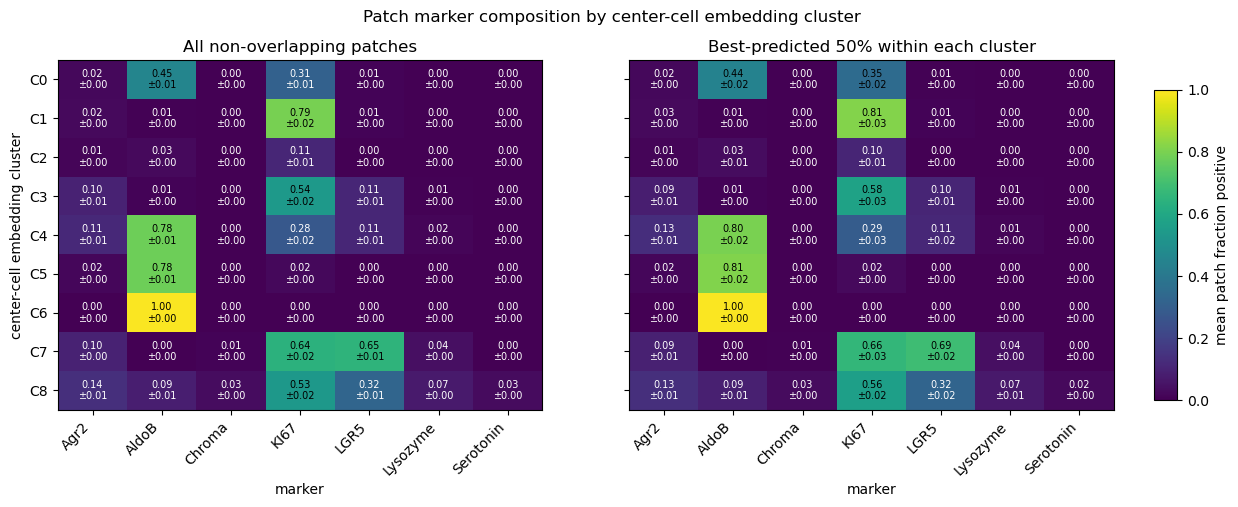

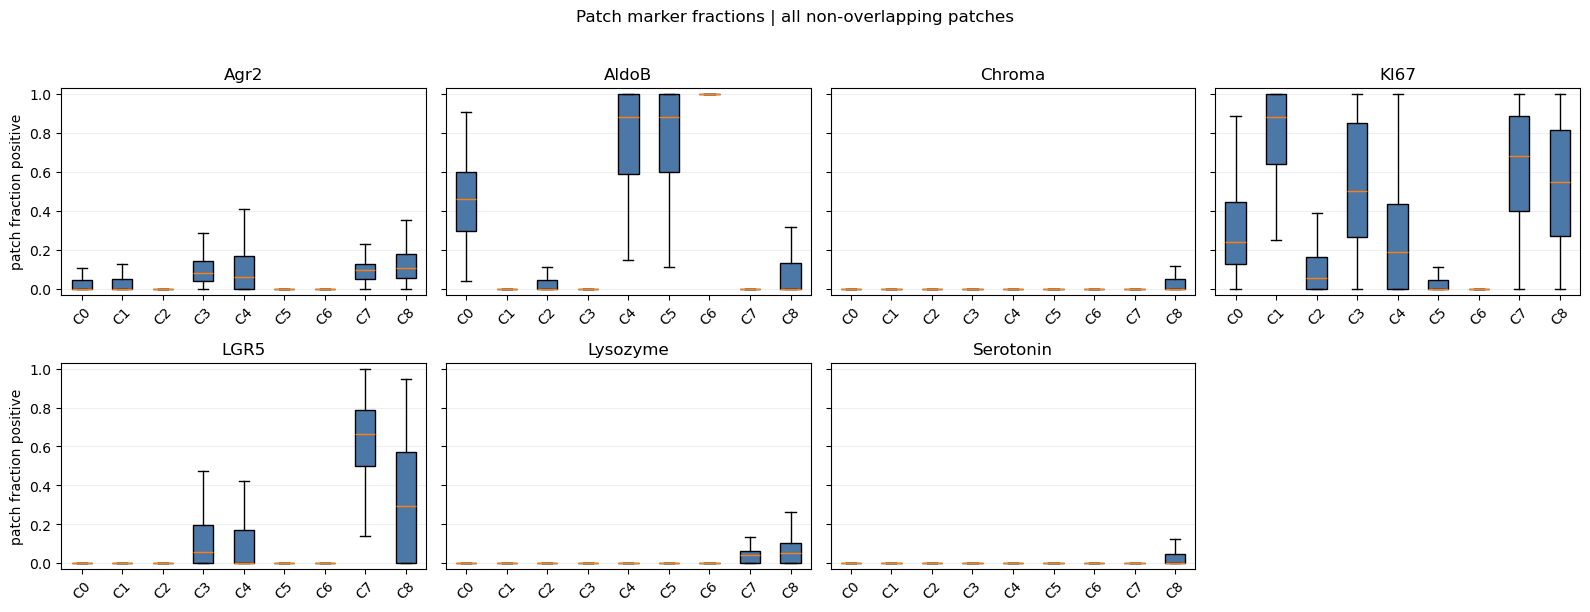

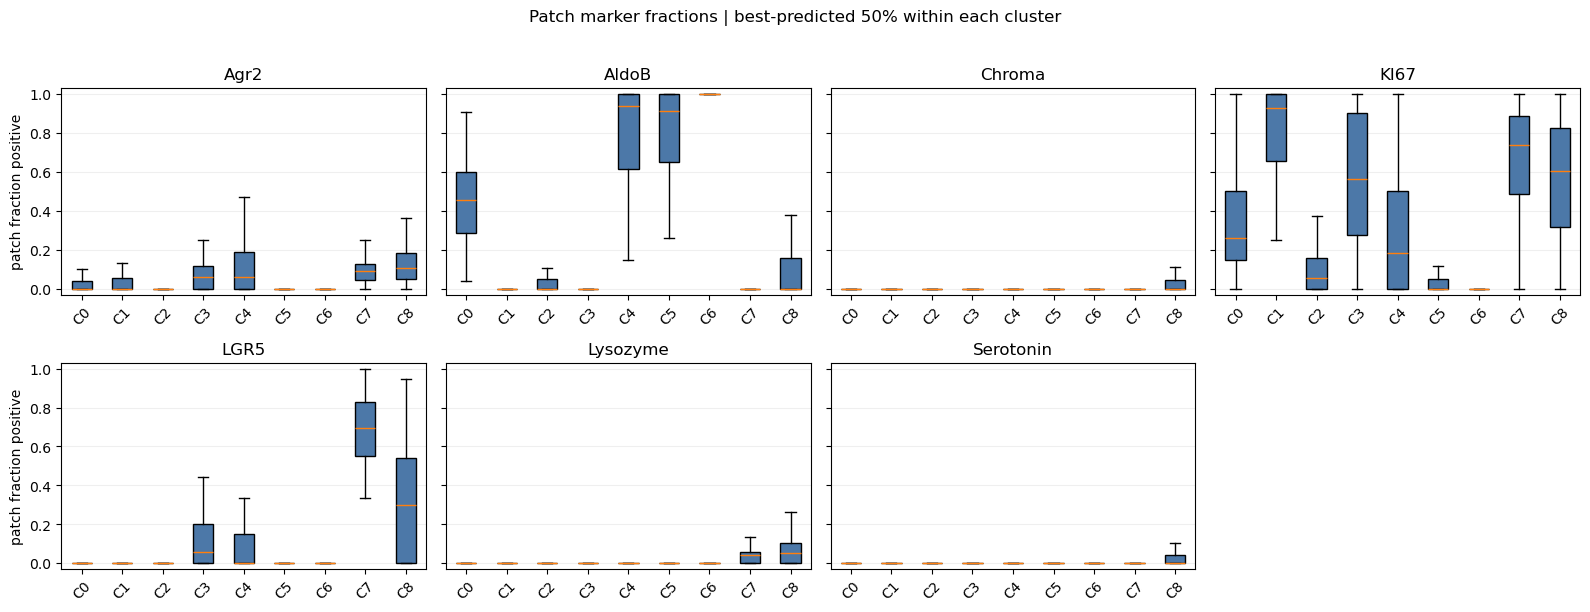

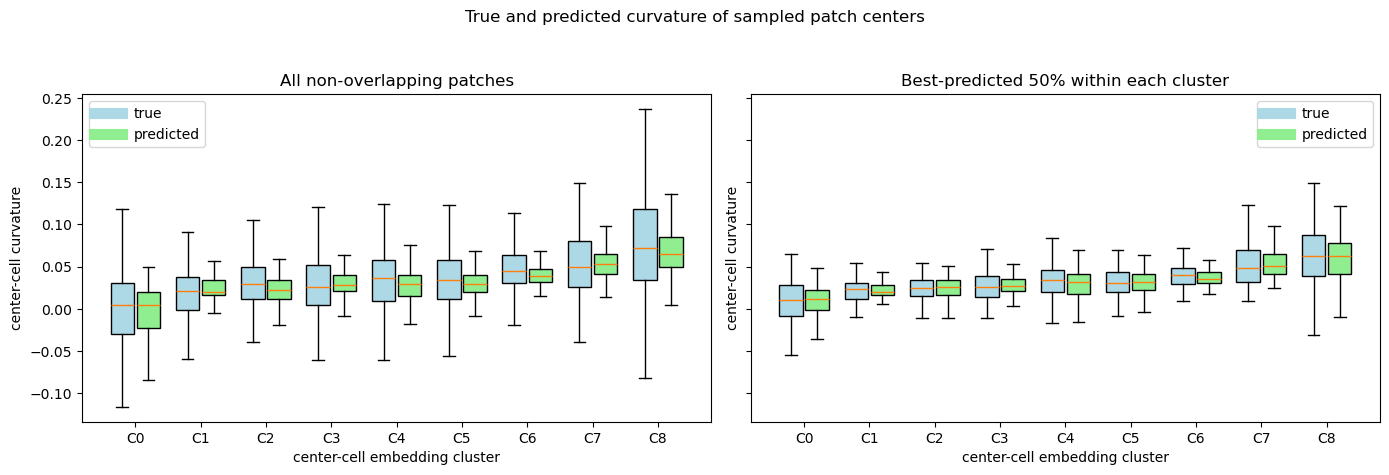

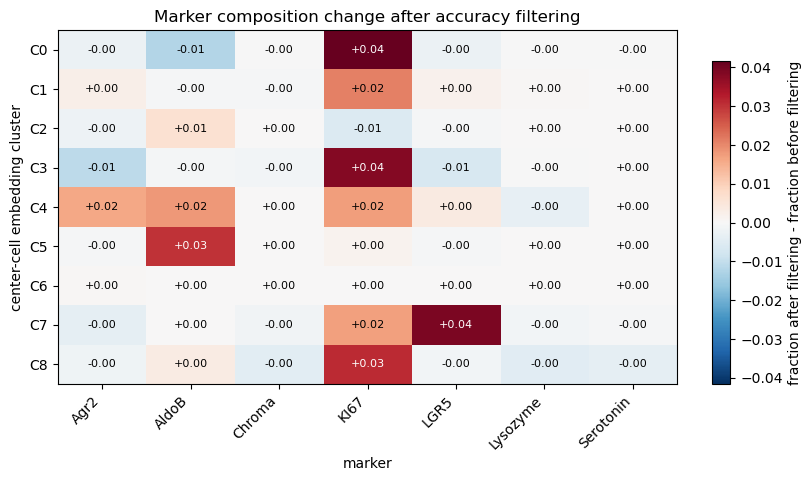

(<Figure size 860x520 with 2 Axes>,
 <Axes: title={'center': 'Marker composition change after accuracy filtering'}, xlabel='marker', ylabel='center-cell embedding cluster'>)

In [99]:
marker_fraction_change_df = marker_fraction_change_table(
    marker_summary_all_df,
    marker_summary_accurate_df,
)

plot_marker_fraction_heatmaps(
    marker_summary_all_df,
    marker_summary_accurate_df,
    filename="patch_marker_fraction_heatmaps_all_vs_accurate",
)
plot_patch_marker_distributions(
    patch_marker_all_df,
    "Patch marker fractions | all non-overlapping patches",
    "patch_marker_distributions_all",
)
plot_patch_marker_distributions(
    patch_marker_accurate_df,
    "Patch marker fractions | best-predicted 50% within each cluster",
    "patch_marker_distributions_accurate_half",
)

plot_patch_curvature_boxplots(
    patch_df,
    accurate_patch_df,
    filename="patch_center_curvature_boxplots_all_vs_accurate",
)
plot_marker_fraction_changes(
    marker_fraction_change_df,
    filename="patch_marker_fraction_changes_after_filtering",
)


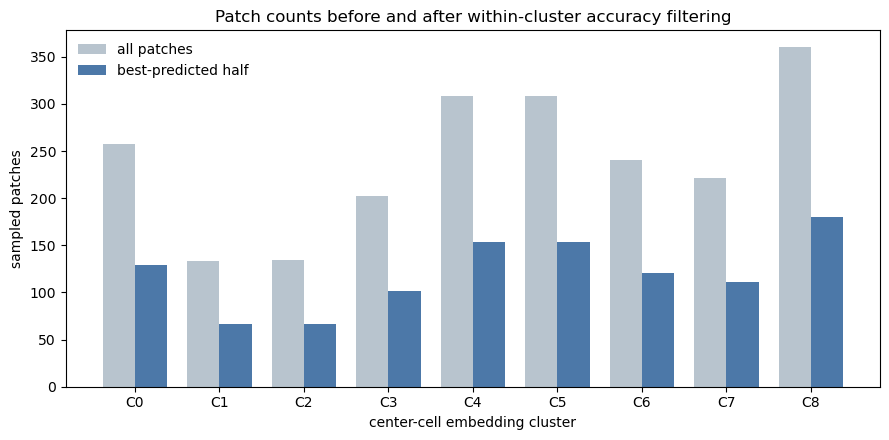

In [100]:
fig, ax = plt.subplots(figsize=(9, 4.5))
clusters = accuracy_filter_summary_df["cluster"].to_numpy(int)
width = 0.38
ax.bar(
    clusters - width / 2,
    accuracy_filter_summary_df["n_available_patches"],
    width=width,
    label="all patches",
    color="#B8C4CE",
)
ax.bar(
    clusters + width / 2,
    accuracy_filter_summary_df["n_kept_patches"],
    width=width,
    label="best-predicted half",
    color="#4C78A8",
)
ax.set_xticks(clusters)
ax.set_xticklabels([f"C{cluster}" for cluster in clusters])
ax.set_xlabel("center-cell embedding cluster")
ax.set_ylabel("sampled patches")
ax.set_title("Patch counts before and after within-cluster accuracy filtering")
ax.legend(frameon=False)
fig.tight_layout()
save_figure(fig, "patch_counts_by_cluster")
plt.show()


## 7. Export Filtered Patch Composition Table


In [101]:
from scripts.export_patch_composition_tables import (
    metadata_value,
    slugify,
    target_vector,
)


def build_filtered_patch_export_table(filtered_patches, graphs, marker_names):
    """Create an export-script-compatible table for retained validation patches."""
    marker_slugs = [slugify(marker) for marker in marker_names]
    rows = []

    for patch in filtered_patches.itertuples(index=False):
        graph = graphs[int(patch.graph_index)]
        patch_nodes = np.asarray(json.loads(patch.patch_node_ids), dtype=np.int64)
        x = graph.x.detach().cpu().numpy()
        y = target_vector(graph)
        patch_x = x[patch_nodes]
        patch_y = y[patch_nodes]

        row = {
            "graph_index": int(patch.graph_index),
            "organoid_str": patch.organoid_str,
            "organoid_id": patch.organoid_id,
            "label_uid": patch.label_uid,
            "dataset": patch.dataset,
            "timepoint": patch.timepoint,
            "center_node_id": int(patch.center_node_id),
            "center_node_original_id": int(patch.center_node_original_id),
            "patch_node_ids": patch.patch_node_ids,
            "sampling_stage": patch.sampling_stage,
            "n_cells_pool": int(len(patch_nodes)),
            "n_cells_organoid": int(graph.x.shape[0]),
            "total_surface_area": metadata_value(
                graph,
                ["total_surface_area", "surface_area"],
            ),
            "total_volume": metadata_value(
                graph,
                ["total_volume", "volume"],
            ),
            "center_curvature": float(y[int(patch.center_node_id)]),
            "pool_mean_curvature": float(np.mean(patch_y)),
            "pool_std_curvature": (
                float(np.std(patch_y, ddof=1)) if len(patch_y) > 1 else 0.0
            ),
            "prediction_depth_2": float(patch.center_predicted_curvature),
            "absolute_error_depth_2": float(patch.center_absolute_error),
            "cluster_depth2": int(patch.cluster),
        }

        for marker_index, slug in enumerate(marker_slugs):
            positive = patch_x[:, marker_index] > 0.5
            row[f"n_{slug}_positive"] = int(positive.sum())
            row[f"frac_{slug}_positive"] = float(positive.mean())
            row[f"center_{slug}_positive"] = int(
                x[int(patch.center_node_id), marker_index] > 0.5
            )
            for hop in range(PATCH_RADIUS + 1):
                row[f"hop_{hop}_{slug}_present"] = int(
                    getattr(patch, f"hop_{hop}_marker_{marker_index}_present")
                )

        rows.append(row)

    return pd.DataFrame(rows)


filtered_patch_export_df = build_filtered_patch_export_table(
    accurate_patch_df,
    g_val_raw,
    marker_names,
)
filtered_patch_export_path = (
    TABLES_DIR / "patch_composition_filtered_validation_predictions_clusters.csv"
)
filtered_patch_export_df.to_csv(filtered_patch_export_path, index=False)

print(
    f"Exported {len(filtered_patch_export_df):,} filtered patches -> "
    f"{filtered_patch_export_path}"
)
display(filtered_patch_export_df.head())


Exported 1,084 filtered patches -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/patch_composition_sampling_analysis/depth2_clusters9_radius2_accurate50_20260609_141604/tables/patch_composition_filtered_validation_predictions_clusters.csv


,graph_index,organoid_str,organoid_id,label_uid,dataset,timepoint,center_node_id,center_node_original_id,patch_node_ids,sampling_stage,...,center_Lysozyme_positive,hop_0_Lysozyme_present,hop_1_Lysozyme_present,hop_2_Lysozyme_present,n_Serotonin_positive,frac_Serotonin_positive,center_Serotonin_positive,hop_0_Serotonin_present,hop_1_Serotonin_present,hop_2_Serotonin_present
0,0,organoid_day4_A02_14,day4_A02_14,day4_A02_14,20250929,day4,111,111,"[6, 12, 20, 25, 32, 34, 35, 43, 91, 102, 111, ...",minimum_coverage,...,0,0,0,0,2,0.095238,1,1,1,0
1,0,organoid_day4_A02_14,day4_A02_14,day4_A02_14,20250929,day4,145,145,"[79, 112, 114, 115, 121, 124, 125, 128, 133, 1...",coverage_maximization,...,0,0,0,0,0,0.000000,0,0,0,0
2,0,organoid_day4_A02_14,day4_A02_14,day4_A02_14,20250929,day4,187,187,"[8, 9, 26, 28, 37, 40, 41, 48, 180, 185, 187, ...",coverage_maximization,...,0,0,0,1,0,0.000000,0,0,0,0
3,1,organoid_day4_A02_24,day4_A02_24,day4_A02_24,20250929,day4,105,105,"[105, 114, 121, 122, 123, 133, 135, 139, 159, ...",coverage_maximization,...,0,0,0,0,0,0.000000,0,0,0,0
4,1,organoid_day4_A02_24,day4_A02_24,day4_A02_24,20250929,day4,131,131,"[106, 109, 113, 117, 118, 119, 130, 131, 141, ...",minimum_coverage,...,0,0,0,1,1,0.045455,0,0,1,0


## 8. Save Tables And Settings

In [102]:
patch_df.to_csv(TABLES_DIR / "non_overlapping_patch_table.csv", index=False)
accurate_patch_df.to_csv(TABLES_DIR / "accurate_half_patch_table.csv", index=False)
organoid_sampling_df.to_csv(TABLES_DIR / "organoid_patch_sampling_summary.csv", index=False)
marker_hop_coverage_df.to_csv(TABLES_DIR / "marker_hop_sampling_coverage.csv", index=False)
patch_marker_all_df.to_csv(TABLES_DIR / "patch_marker_values_all.csv", index=False)
patch_marker_accurate_df.to_csv(TABLES_DIR / "patch_marker_values_accurate_half.csv", index=False)
marker_summary_all_df.to_csv(TABLES_DIR / "patch_marker_summary_all.csv", index=False)
marker_summary_accurate_df.to_csv(
    TABLES_DIR / "patch_marker_summary_accurate_half.csv",
    index=False,
)
marker_fraction_change_df.to_csv(
    TABLES_DIR / "patch_marker_fraction_changes_after_filtering.csv",
    index=False,
)
accuracy_filter_summary_df.to_csv(
    TABLES_DIR / "accuracy_filter_summary_by_cluster.csv",
    index=False,
)
cluster_summary_df.to_csv(TABLES_DIR / "validation_cluster_summary.csv", index=False)


In [103]:
settings = {
    "experiment_group": EXPERIMENT_GROUP,
    "dataset_name": DATASET_NAME,
    "target_indices": TARGET_INDICES,
    "target_index_for_analysis": TARGET_INDEX_FOR_ANALYSIS,
    "filtering": {
        "exclude_timepoint": EXCLUDE_TIMEPOINT,
        "filter_blacklisted_organoids": FILTER_BLACKLISTED_ORGANOIDS,
        "blacklist_n_keys": len(blacklist),
        "apply_quality_filters": APPLY_QUALITY_FILTERS,
        "missing_complexity_group": MISSING_COMPLEXITY_GROUP,
        "sphericity_max": SPHERICITY_MAX,
        "spherical_marker_diversity_min": SPHERICAL_MARKER_DIVERSITY_MIN,
        "complexity_min": COMPLEXITY_MIN,
        "interpolate_target_outliers": INTERPOLATE_TARGET_OUTLIERS,
        "outlier_clip_quantiles": OUTLIER_CLIP_QUANTILES,
    },
    "split": {
        "validation_fraction": VAL_FRAC,
        "seed": SPLIT_SEED,
        "n_train_graphs": len(g_train),
        "n_validation_graphs": len(g_val),
    },
    "model": {
        "class": "GINCurvature",
        "num_layers": NUM_LAYERS,
        "hidden_dim": HIDDEN_DIM,
        "dropout": DROPOUT,
        "norm": NORM,
        "residual": RESIDUAL,
        "use_global_features": USE_GLOBAL_FEATURES,
        "subtract_global_baseline": SUBTRACT_GLOBAL_BASELINE,
    },
    "training": {
        "lr": LR,
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "num_workers": NUM_WORKERS,
        "edge_loss_weight": EDGE_LOSS_WEIGHT,
        "edge_loss_params": EDGE_LOSS_PARAMS,
    },
    "clustering": {
        "n_clusters": N_CLUSTERS,
        "embedding_variant": EMBEDDING_VARIANT,
        "residualize_global": RESIDUALIZE_GLOBAL_FOR_CLUSTERING,
        "method": CLUSTERING_METHOD,
        "covariance_type": COVARIANCE_TYPE,
        "standardize_embeddings": STANDARDIZE_EMBEDDINGS,
        "pca_dim": PCA_DIM,
        "seed": CLUSTER_SEED,
        "labels_reordered_by": "median true curvature",
    },
    "patch_sampling": {
        "radius": PATCH_RADIUS,
        "strict_node_disjointness": True,
        "sampling_strategy": "minimum marker-hop coverage then coverage-maximized maximal packing",
        "minimum_marker_hop_coverage": MIN_MARKER_HOP_COVERAGE,
        "coverage_candidate_pool": COVERAGE_CANDIDATE_POOL,
        "max_stage2_patches": MAX_STAGE2_PATCHES,
        "covered_hops": list(range(PATCH_RADIUS + 1)),
        "seed": PATCH_SEED,
        "cluster_assignment": "cluster of center cell",
        "marker_statistic_observation_unit": "patch",
    },
    "accuracy_filter": {
        "metric": "absolute center-cell prediction error",
        "fraction_kept_per_cluster": ACCURATE_PATCH_FRACTION,
        "minimum_kept_per_cluster": ACCURATE_PATCH_MIN_PER_CLUSTER,
    },
    "marker_names": marker_names,
    "n_graphs_after_filtering": len(graphs),
    "n_sampled_patches": len(patch_df),
    "n_accurate_patches": len(accurate_patch_df),
}

with open(SAVE_DIR / "settings.json", "w") as handle:
    json.dump(jsonable(settings), handle, indent=2)
with open(SAVE_DIR / "results.pkl", "wb") as handle:
    pickle.dump({
        "metrics": metrics,
        "history": history,
        "split_info": split_info,
        "target_outlier_info": target_outlier_info,
        "cluster_labels": labels,
        "cluster_label_mapping": old_to_new,
        "patch_df": patch_df,
        "accurate_patch_mask": accurate_patch_mask,
        "marker_summary_all_df": marker_summary_all_df,
        "marker_summary_accurate_df": marker_summary_accurate_df,
        "marker_fraction_change_df": marker_fraction_change_df,
        "marker_hop_coverage_df": marker_hop_coverage_df,
    }, handle)

print("Saved patch sampling analysis to", SAVE_DIR)


Saved patch sampling analysis to /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/patch_composition_sampling_analysis/depth2_clusters9_radius2_accurate50_20260609_141604
